In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler

In [2]:
data = pd.read_csv("/content/Social_Network_Ads.csv")

In [3]:
data.sample(5)

,User ID,Gender,Age,EstimatedSalary,Purchased
350,15800515,Female,38,113000,1
44,15715541,Female,28,84000,0
90,15684801,Male,22,81000,0
291,15596522,Male,49,89000,1
290,15586757,Male,39,134000,1


In [9]:
# It is recommended to do train test split before standardization and normalization

X = data[["Age","EstimatedSalary"]]
y = data["Purchased"]

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=32)

# **Standardization**
AKA Z-Score Normalization

**Formula** : For each column, new_value = (old_value - mean)/std

After Scaling, the mean of new column values is approx 0 and standard deviation is approx 1

Use Standardization for:


*   KNN
*   K Means Clustering
*   PCA
*   ANN
*   Gradient Descent


Not necessary to use Standardization for:
*   Decision Trees
*   Random Forest
*   Boosting


In [16]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Returns numpy array
X_train_scaled

array([[ 1.60494768e-01,  8.81554170e-02],
       [ 1.43708796e+00, -9.52245711e-01],
       [ 1.92808533e+00,  1.54471700e+00],
       [-1.21429789e+00,  2.66509896e-01],
       [ 1.14248953e+00,  1.17881163e-01],
       [ 1.63348691e+00,  1.12855654e+00],
       [-7.23300515e-01,  1.09883080e+00],
       [ 6.51492148e-01,  2.05005469e+00],
       [ 2.22268376e+00, -1.07114870e+00],
       [ 8.47891100e-01, -1.13060019e+00],
       [ 1.14248953e+00, -1.24950318e+00],
       [-2.32303135e-01, -1.48730915e+00],
       [-1.70529527e+00,  4.74590122e-01],
       [-1.50889632e+00, -1.54676064e+00],
       [-2.32303135e-01,  2.07058403e-01],
       [-8.21499991e-01,  3.85412882e-01],
       [ 6.22952925e-02, -1.49650555e-01],
       [-1.11609842e+00, -1.60621213e+00],
       [-1.34103659e-01, -2.09102048e-01],
       [-8.21499991e-01, -6.84713992e-01],
       [ 4.55093196e-01,  8.81554170e-02],
       [ 8.47891100e-01, -1.24950318e+00],
       [-9.19699466e-01, -3.28005034e-01],
       [ 7.

In [18]:
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

print(X_train_scaled.sample(5))
print("\n")
print(X_train_scaled.describe())

          Age  EstimatedSalary
198  1.731686        -0.922520
58  -1.705295        -1.398132
127  1.928085         0.117881
316  0.455093        -0.001022
20   0.455093         0.088155


                Age  EstimatedSalary
count  3.200000e+02     3.200000e+02
mean  -1.554312e-16    -1.110223e-17
std    1.001566e+00     1.001566e+00
min   -1.901694e+00    -1.635938e+00
25%   -7.233005e-01    -7.738912e-01
50%   -3.590418e-02    -1.021823e-03
75%    6.514921e-01     5.043159e-01
max    2.222684e+00     2.377038e+00


In [20]:
print(X_train_scaled.mean())
print(X_train_scaled.std(ddof=0))

Age               -1.554312e-16
EstimatedSalary   -1.110223e-17
dtype: float64
Age                1.0
EstimatedSalary    1.0
dtype: float64


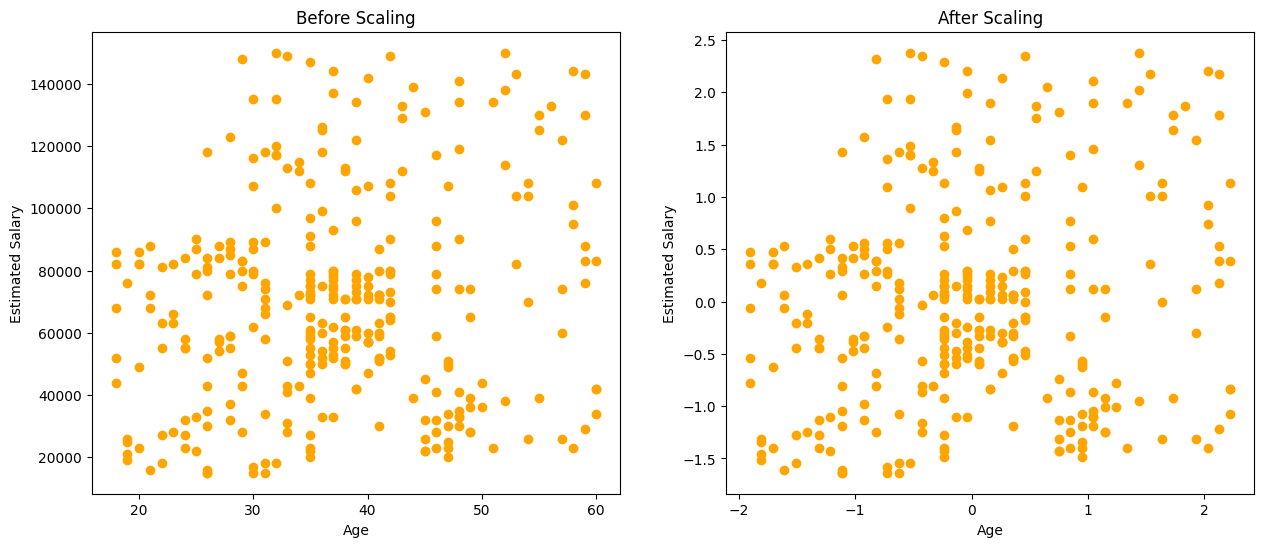

In [23]:
# Effect of Scaling

fig, ax = plt.subplots(ncols=2, figsize=(15,6))

ax[0].scatter(X_train["Age"],X_train["EstimatedSalary"],color="orange")
ax[1].scatter(X_train_scaled["Age"],X_train_scaled["EstimatedSalary"],color="orange")

ax[0].set_title("Before Scaling")
ax[1].set_title("After Scaling")

ax[0].set_xlabel("Age")
ax[0].set_ylabel("Estimated Salary")

ax[1].set_xlabel("Age")
ax[1].set_ylabel("Estimated Salary")


fig.show()

In [24]:
# Outliers are not affected by standardization
# Their distance from main points remain same

# **NORMALIZATION**
Done by MinMaxScaling

Formula:- new_value = (old_value - min_value_of_data)/(max_value_of_data - min_value_of_data)

After MinMaxScaling, the min and max values of all scaled columns will be 0 and 1 respectively

X_i_new = (X_i - X_min)/(X_max - X_min)

In [25]:
data = pd.read_csv("/content/wine_data.csv", header=None, usecols=[0,1,2])
data.columns = ["Class Label","Alcohol","Malic Acid"]
data.sample(5)

,Class Label,Alcohol,Malic Acid
6,1,14.39,1.87
123,2,13.05,5.80
92,2,12.69,1.53
130,3,12.86,1.35
96,2,11.81,2.12


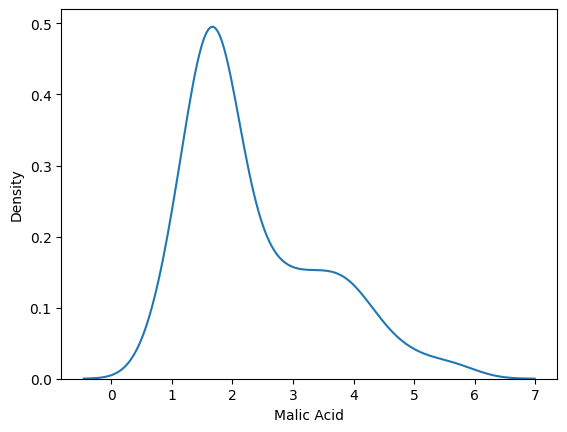

In [27]:
sns.kdeplot(data["Malic Acid"])
plt.show()

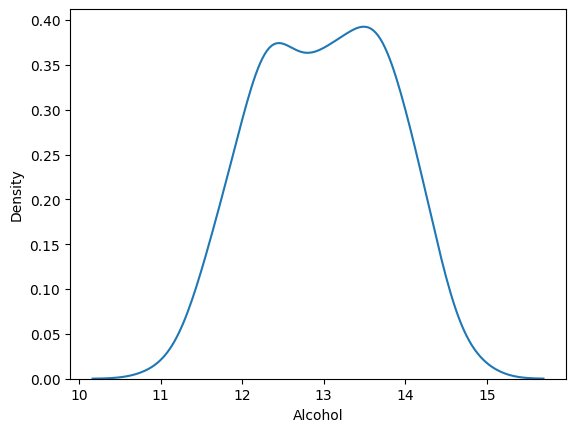

In [28]:
sns.kdeplot(data["Alcohol"])
plt.show()

In [30]:
# train_test_split

X = data.drop("Class Label",axis=1)
y = data["Class Label"]

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=32)
X_train.sample(5)

,Alcohol,Malic Acid
71,13.86,1.51
38,13.07,1.50
105,12.42,2.55
177,14.13,4.10
52,13.82,1.75


In [32]:
scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

In [33]:
X_train.describe()

,Alcohol,Malic Acid
count,142.000000,142.000000
mean,12.963803,2.310986
std,0.837089,1.119533
min,11.030000,0.890000
25%,12.290000,1.580000
50%,12.960000,1.850000
75%,13.677500,3.020000
max,14.830000,5.650000


In [34]:
X_train_scaled.describe()

,Alcohol,Malic Acid
count,142.000000,142.000000
mean,0.508895,0.298526
std,0.220286,0.235196
min,0.000000,0.000000
25%,0.331579,0.144958
50%,0.507895,0.201681
75%,0.696711,0.447479
max,1.000000,1.000000


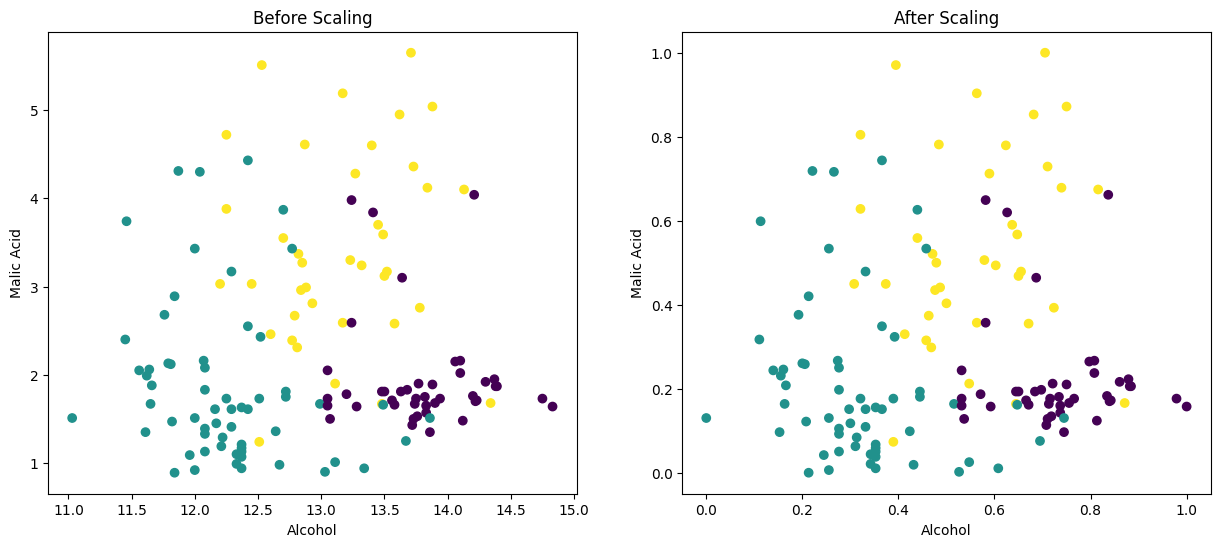

In [39]:
# Effect of Scaling

fig, ax = plt.subplots(ncols=2, figsize=(15,6))

ax[0].scatter(X_train["Alcohol"],X_train["Malic Acid"],c=y_train)
ax[1].scatter(X_train_scaled["Alcohol"],X_train_scaled["Malic Acid"],c=y_train)

ax[0].set_title("Before Scaling")
ax[1].set_title("After Scaling")

ax[0].set_xlabel("Alcohol")
ax[0].set_ylabel("Malic Acid")

ax[1].set_xlabel("Alcohol")
ax[1].set_ylabel("Malic Acid")

fig.show()

# Normalization VS Standardization
1) Mostly use Standardization
2) Use MinMaxScaling generally when you know range of the data like in Image processing, we know that the values will be between 0-255 so use that